In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import timm
from torch.utils.data import Dataset, DataLoader

In [3]:
class BiplanarXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None, voxel_transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.voxel_transform = voxel_transform
        self.samples = []

        # Structure: ../data/processed/{patientID}/DRR/{side}/la.png, pa.png
        for patient_id in os.listdir(root_dir):
            drr_path = os.path.join(root_dir, patient_id, "DRR")
            for side in ["left", "right"]:
                la_path = os.path.join(drr_path, side, "la.png")
                pa_path = os.path.join(drr_path, side, "pa.png")
                model_path = os.path.join(root_dir, patient_id, "model", f"{side}.npz")

                if os.path.exists(la_path) and os.path.exists(pa_path) and os.path.exists(model_path):
                    self.samples.append({
                        "la": la_path,
                        "pa": pa_path,
                        "model": model_path,
                        "patient_id": patient_id,
                        "side": side
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        la_img = Image.open(sample["la"]).convert("RGB")
        pa_img = Image.open(sample["pa"]).convert("RGB")

        if self.transform:
            la_img = self.transform(la_img)
            pa_img = self.transform(pa_img)

        # Load voxel from .npz file
        voxel_npz = np.load(sample["model"])  # expects key like "voxel"
        if "voxel" in voxel_npz:
            voxel = voxel_npz["voxel"]
        else:
            voxel = voxel_npz[list(voxel_npz.keys())[0]]  # fallback to first key

        voxel_tensor = torch.from_numpy(voxel).float()  # assume shape [D, H, W]
        print(f"Loaded voxel shape: {voxel_tensor.shape}")

        # Resize or pad/crop to [8, 56, 56] if needed
        # Add channel dim: [1, D, H, W]
        voxel_tensor = voxel_tensor.unsqueeze(0)

        # Optionally apply voxel transform
        if self.voxel_transform:
            voxel_tensor = self.voxel_transform(voxel_tensor)

        return {
            "la": la_img,
            "pa": pa_img,
            "voxel": voxel_tensor,  # ground truth
            "patient_id": sample["patient_id"],
            "side": sample["side"]
        }


In [4]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


# Concatenation

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("convnextv2_tiny", pretrained=False, num_classes=0)  # no classification head
model.load_state_dict(torch.load("../convnextv2_finetuned_simclr.pth"))
model.eval().to(device)


ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [5]:
def extract_features(batch, model):
    with torch.no_grad():
        la_feat = model(batch["la"].to(device))
        pa_feat = model(batch["pa"].to(device))
        fused_feat = torch.cat([la_feat, pa_feat], dim=1)  # [B, 2*feature_dim]
    return fused_feat


In [6]:
dataset = BiplanarXrayDataset(root_dir="../data/processed", transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=False)

for batch in tqdm(dataloader):
    features = extract_features(batch, model)  # features shape: [B, 2*feature_dim]
    print(f"Processed batch with features shape: {features.shape}")

print(features[0])


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.37s/it]

Processed batch with features shape: torch.Size([6, 1536])
tensor([-0.3632,  0.7382, -0.3106,  ...,  0.6672,  1.5785,  1.4623])


# Cross-Attention Fusion

In [5]:
# Cross-Attention Module
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super(CrossAttention, self).__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, la_feat, pa_feat):
        Q = self.query(la_feat)
        K = self.key(pa_feat)
        V = self.value(pa_feat)
        attn_weights = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) * self.scale, dim=-1)
        attn_output = torch.matmul(attn_weights, V)
        return attn_output + la_feat  # skip connection



In [6]:
# ConvNeXt-based Encoder with skip outputs
class ConvNeXtEncoder(nn.Module):
    def __init__(self, backbone_name='convnextv2_tiny', weight_path=None):
        super(ConvNeXtEncoder, self).__init__()
        self.encoder = timm.create_model(backbone_name, pretrained=True, features_only= True)  # no classification head
        if weight_path is not None:
            state_dict = torch.load(weight_path, map_location='cpu')
            self.encoder.load_state_dict(state_dict)
            print(f"✅ Loaded pretrained weights from {weight_path}")

    def forward(self, x):
        return self.encoder(x)  # [stage1, stage2, stage3, stage4]



In [7]:
class BiPlanarFeatureFusion(nn.Module):
    def __init__(self, backbone_name='convnextv2_tiny', weight_path=None, depth=8):
        super(BiPlanarFeatureFusion, self).__init__()
        self.encoder = ConvNeXtEncoder(backbone_name, weight_path)
        feature_dims = [f['num_chs'] for f in self.encoder.encoder.feature_info]

        # Define output channels to increase at each level
        self.out_channels = [64, 128, 256, 512]  # Adjust this list if you use more/fewer levels

        self.cross_attn_blocks = nn.ModuleList([
            CrossAttention(dim) for dim in feature_dims
        ])

        # 2D → 3D projection layers with increasing output channels
        self.to3d = nn.ModuleList([
            nn.Conv2d(c, out_ch, kernel_size=1) for c, out_ch in zip(feature_dims, self.out_channels)
        ])

        self.expand3d = nn.ModuleList([
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1) for out_ch in self.out_channels
        ])

        self.depth = depth  # Depth of the 3D volume

    def load_encoder_weights(self, path):
        state_dict = torch.load(path, map_location='cpu')
        self.encoder.load_state_dict(state_dict)

    def forward(self, la_img, pa_img):
        la_feats = self.encoder(la_img)
        pa_feats = self.encoder(pa_img)

        fused_feats = []
        fused_feats_3d = []

        for i, (la_f, pa_f, ca, conv2d, conv3d) in enumerate(zip(
            la_feats, pa_feats, self.cross_attn_blocks, self.to3d, self.expand3d
        )):
            B, C, H, W = la_f.shape

            # Flatten for attention
            la_f_flat = la_f.flatten(2).transpose(1, 2)  # [B, HW, C]
            pa_f_flat = pa_f.flatten(2).transpose(1, 2)  # [B, HW, C]
            fused_flat = ca(la_f_flat, pa_f_flat)

            # Reshape back to [B, C, H, W]
            fused_2d = fused_flat.transpose(1, 2).reshape(B, C, H, W)
            fused_feats.append(fused_2d)

            # 2D → 3D projection
            f2d_proj = conv2d(fused_2d)                             # [B, out_ch, H, W]
            f3d = f2d_proj.unsqueeze(2)  # [B, C, 1, H, W]
            f3d = F.interpolate(f3d, size=(self.depth, H, W), mode='trilinear', align_corners=False)
            f3d = conv3d(f3d)                                       # [B, out_ch, D, H, W]
            fused_feats_3d.append(f3d)

        return fused_feats, fused_feats_3d


In [8]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset and Loader
dataset = BiplanarXrayDataset(root_dir="../data/processed", transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
print("Dataset size:", len(dataset))

# Instantiate the model
model = BiPlanarFeatureFusion(backbone_name='convnextv2_tiny', weight_path="../checkpoints/simclr_convnext_v2_tiny_encoder_only.pth", depth=32).to(device)
model.eval()

# Inference loop
with torch.no_grad():
    for batch in dataloader:
        la_input = batch["la"].to(device)  # shape: (B, 3, H, W)
        pa_input = batch["pa"].to(device)  # shape: (B, 3, H, W)
        patient_ids = batch["patient_id"]
        sides = batch["side"]

        # Your fused feature map comes from la + pa → fused = model(...)
        print("First sample in this batch is from patient:", patient_ids)
        print("Side:", sides)
        print("Input shapes - LA:", la_input.shape, "PA:", pa_input.shape)

        fused_feats_2d, fused_feats_3d = model(la_input, pa_input)

        for i, f in enumerate(fused_feats_2d):
            print(f"Fused 2D feature[{i}] shape: {f.shape}")

        for i, f in enumerate(fused_feats_3d):
            print(f"Fused 3D feature[{i}] shape: {f.shape}")



Dataset size: 8
✅ Loaded pretrained weights from ../checkpoints/simclr_convnext_v2_tiny_encoder_only.pth
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
Loaded voxel shape: torch.Size([128, 128, 128])
First sample in this batch is from patient: ['z035', 'z035', '006', '006', '010', '010', '002', '002']
Side: ['left', 'right', 'left', 'right', 'left', 'right', 'left', 'right']
Input shapes - LA: torch.Size([8, 3, 224, 224]) PA: torch.Size([8, 3, 224, 224])
Fused 2D feature[0] shape: torch.Size([8, 96, 56, 56])
Fused 2D feature[1] shape: torch.Size([8, 192, 28, 28])
Fused 2D feature[2] shape: torch.Size([8, 384, 14, 14])
Fused 2D feature[3] shape: torch.Size([8, 768, 7, 7])
Fused 3D feature[0] shape: torc

In [ ]:
class UNet3DDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up3 = nn.ConvTranspose3d(512, 256, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv3 = self.conv_block(256 + 256, 256)

        self.up2 = nn.ConvTranspose3d(256, 128, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv2 = self.conv_block(128 + 128, 128)

        self.up1 = nn.ConvTranspose3d(128, 64, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv1 = self.conv_block(64 + 64, 64)

        # self.up3 = nn.ConvTranspose3d(512, 256, kernel_size=2, stride=2)
        # self.conv3 = self.conv_block(512, 256)

        # self.up2 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        # self.conv2 = self.conv_block(256, 128)

        # self.up1 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        # self.conv1 = self.conv_block(128, 64)

        self.final = nn.Conv3d(64, 1, kernel_size=1)  # Output 1 channel: voxel occupancy

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv3d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, feats):  # feats = list of 3D features [level0, level1, level2, level3]
        x0, x1, x2, x3 = feats  # shallow → deep

        x = self.up3(x3)  # [B, 256, 8, 14, 14]
        x = torch.cat([x, x2], dim=1)  # skip connection
        x = self.conv3(x)

        x = self.up2(x)  # [B, 128, 8, 28, 28]
        x = torch.cat([x, x1], dim=1)
        x = self.conv2(x)

        x = self.up1(x)  # [B, 64, 8, 56, 56]
        x = torch.cat([x, x0], dim=1)
        x = self.conv1(x)

        out = self.final(x)  # [B, 1, 8, 56, 56]
        return out


In [38]:
for f in fused_feats_3d:
    print(f"Fused 3D feature shape: {f.shape}")

Fused 3D feature shape: torch.Size([8, 64, 8, 56, 56])
Fused 3D feature shape: torch.Size([8, 128, 8, 28, 28])
Fused 3D feature shape: torch.Size([8, 256, 8, 14, 14])
Fused 3D feature shape: torch.Size([8, 512, 8, 7, 7])


In [39]:
decoder = UNet3DDecoder().to(device)
decoder.eval()

with torch.no_grad():
    output_voxel = decoder(fused_feats_3d)
    print("Output voxel shape:", output_voxel.shape)  # Expect: [B, 1, 8, 56, 56]


Output voxel shape: torch.Size([8, 1, 128, 128, 128])


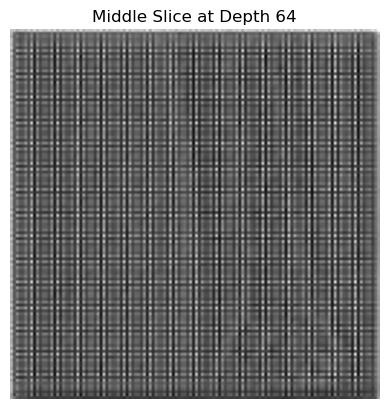

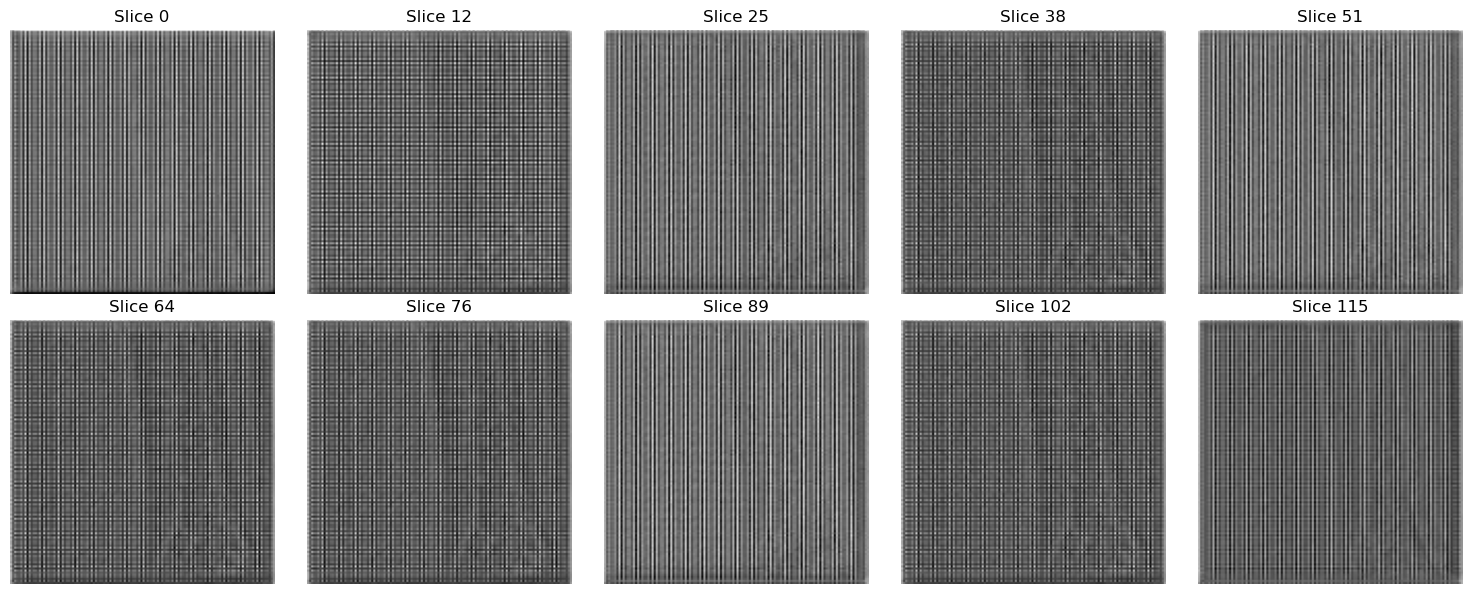

In [45]:
import matplotlib.pyplot as plt

# Assume output_voxel shape: [B, 1, D, H, W]
# Select batch 0 and channel 0 explicitly for safety
voxel = output_voxel[4, 0].cpu().numpy()  # Shape: [D, H, W]

# Visualize middle slice
slice_idx = voxel.shape[0] // 2
plt.imshow(voxel[slice_idx], cmap='gray')
plt.title(f"Middle Slice at Depth {slice_idx}")
plt.axis('off')
plt.show()

# Plot 10 evenly spaced slices
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
num_slices = voxel.shape[0]
for i, ax in enumerate(axs.flat):
    slice_idx = i * num_slices // 10
    ax.imshow(voxel[slice_idx], cmap='gray')
    ax.set_title(f"Slice {slice_idx}")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [43]:
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)  # apply sigmoid since output is logits
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)

    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

decoder = UNet3DDecoder().to(device)
fusion_model = BiPlanarFeatureFusion().to(device)  # assuming encoder is frozen

bce_loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-4)


In [44]:
num_epochs = 50
for epoch in range(num_epochs):
    decoder.train()
    fusion_model.eval()  # assuming frozen encoder

    total_loss = 0
    for batch in dataloader:
        la_img = batch['la'].to(device)           # [B, 3, H, W]
        pa_img = batch['pa'].to(device)
        gt_voxel = batch['voxel'].to(device)      # [B, 1, D, H, W] = [B, 1, 128, 128, 128]

        with torch.no_grad():
            _, fused_feats_3d = fusion_model(la_img, pa_img)

        pred_voxel = decoder(fused_feats_3d)

        # Option 1: Combined BCE + Dice Loss
        # loss = 0.5 * bce_loss(pred_voxel, gt_voxel) + 0.5 * dice_loss(pred_voxel, gt_voxel)

        # Option 2: Just Dice loss
        loss = dice_loss(pred_voxel, gt_voxel)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(dataloader):.4f}")

Epoch 1/50, Loss: 0.9239
Epoch 2/50, Loss: 0.9173
Epoch 3/50, Loss: 0.9130
Epoch 4/50, Loss: 0.9088
Epoch 5/50, Loss: 0.9040
Epoch 6/50, Loss: 0.8979
Epoch 7/50, Loss: 0.8903
Epoch 8/50, Loss: 0.8835
Epoch 9/50, Loss: 0.8759
Epoch 10/50, Loss: 0.8696
Epoch 11/50, Loss: 0.8659
Epoch 12/50, Loss: 0.8598
Epoch 13/50, Loss: 0.8571
Epoch 14/50, Loss: 0.8582
Epoch 15/50, Loss: 0.8493
Epoch 16/50, Loss: 0.8504
Epoch 17/50, Loss: 0.8473
Epoch 18/50, Loss: 0.8469
Epoch 19/50, Loss: 0.8463
Epoch 20/50, Loss: 0.8424
Epoch 21/50, Loss: 0.8446
Epoch 22/50, Loss: 0.8418
Epoch 23/50, Loss: 0.8398
Epoch 24/50, Loss: 0.8388
Epoch 25/50, Loss: 0.8380
Epoch 26/50, Loss: 0.8378
Epoch 27/50, Loss: 0.8363
Epoch 28/50, Loss: 0.8358
Epoch 29/50, Loss: 0.8357
Epoch 30/50, Loss: 0.8333
Epoch 31/50, Loss: 0.8343
Epoch 32/50, Loss: 0.8329
Epoch 33/50, Loss: 0.8325
Epoch 34/50, Loss: 0.8321
Epoch 35/50, Loss: 0.8315
Epoch 36/50, Loss: 0.8313
Epoch 37/50, Loss: 0.8306
Epoch 38/50, Loss: 0.8301
Epoch 39/50, Loss: 0.

In [15]:
import torch
import torch.nn as nn

class DimensionExpansion(nn.Module):
    def __init__(self, input_channels=768, depth=8):
        super(DimensionExpansion, self).__init__()
        self.depth = depth

        # You can first lift the 2D feature into a pseudo-3D by repeating along D
        # Then use a Conv3D block to refine the features
        self.expand_and_project = nn.Sequential(
            nn.Conv3d(input_channels, input_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(input_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # x: [B, C, H, W] → [B, C, D, H, W] by unsqueezing and repeating
        x = x.unsqueeze(2).repeat(1, 1, self.depth, 1, 1)  # Add depth dimension
        x = self.expand_and_project(x)
        return x


In [16]:

dim_expander = DimensionExpansion(input_channels=768, depth=8)

expanded = dim_expander(f)
print(expanded.shape)  # Should be [6, 768, 8, 7, 7]


torch.Size([8, 768, 8, 7, 7])


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------- Dimension Expansion -------------
class DimensionExpansion(nn.Module):
    def __init__(self, input_channels=768, depth=16):
        super(DimensionExpansion, self).__init__()
        self.depth = depth

        self.expand = nn.Sequential(
            nn.Conv3d(input_channels, input_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(input_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = x.unsqueeze(2).repeat(1, 1, self.depth, 1, 1)  # [B, C, D, H, W]
        return self.expand(x)

# ----------- Simple 3D U-Net Decoder -------------
class UNet3D(nn.Module):
    def __init__(self, in_channels=768, out_channels=1, base_filters=64):
        super(UNet3D, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, base_filters)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = self.conv_block(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool3d(2)

        # Bottleneck
        self.bottleneck = self.conv_block(base_filters * 2, base_filters * 4)

        # Decoder
        self.up2 = nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(base_filters * 2, base_filters)

        # Output
        self.final = nn.Conv3d(base_filters, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        up2 = self.up2(b)
        cat2 = torch.cat([up2, e2], dim=1)
        d2 = self.dec2(cat2)

        up1 = self.up1(d2)
        cat1 = torch.cat([up1, e1], dim=1)
        d1 = self.dec1(cat1)

        out = self.final(d1)  # Output shape: [B, 1, D, H, W]
        return out

# ----------- Pipeline Wrapper -------------
class FeatureTo3DModel(nn.Module):
    def __init__(self, in_channels=768, depth=16, out_channels=1):
        super(FeatureTo3DModel, self).__init__()
        self.dim_expander = DimensionExpansion(in_channels, depth)
        self.unet3d = UNet3D(in_channels, out_channels)

    def forward(self, fused_2d_feats):
        vol3d = self.dim_expander(fused_2d_feats)
        output_3d = self.unet3d(vol3d)
        return output_3d


In [45]:
model = FeatureTo3DModel(in_channels=768, depth=16, out_channels=1)

output_3d = model(f)
print(output_3d.shape)  # Expected: [6, 1, D, H, W] like [6, 1, 16, 7, 7]


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 2 but got size 3 for tensor number 1 in the list.